# TOI-700 d: multi-sector transit coverage audit

**Scientific question:** Does a simple multi-sector audit significantly recover the 37.426-day transit?

## Scientific audit protocol

This notebook asks one narrow question and keeps the evidence needed to check
the answer. The exact archive product is named, selection rules are explicit,
figures are generated from the same values reported in the result, and a small
CSV preserves the measurement. A fixed random seed makes resampling repeatable.

Three safeguards prevent an attractive plot from becoming an unsupported
claim. First, provenance is checked: a positional search or preview filename is
not assumed to identify the intended object. Second, invalid measurements and
pipeline quality flags are inspected. Third, a reasonable analysis choice is
changed. Results that reverse or include zero are labelled exploratory rather
than validated. Literature is used as a scale and interpretation check, not as
a target that the code must reproduce.

Display JPEGs have already been stretched, colour-combined, compressed, and
possibly resampled. Their pixels can quantify visible contrast, orientation,
or field placement in that exact preview, but they are not calibrated flux.
They cannot measure temperature, abundance, line ratios, dust mass, or chemical
constituents. Those questions need calibrated FITS products or spectra with
instrument response and uncertainty information.

Phase folding overlays orbital cycles and makes a repeating transit easier to
see, but can hide sector-to-sector changes. For that reason the stored tables
retain time and sector information. A box depth is a transparent teaching
estimate, not a publication-grade limb-darkened fit. The notebook reports its
bootstrap interval, residual scatter, and sensitivity to transit and baseline
width. Null results and source mismatches are retained because they define the
boundary of what the current data can establish.

Each saved figure has a specific job. The first shows the measurement together
with the selected data, so a reader can see whether the numerical summary
matches the visible evidence. The second changes an assumption or processing
choice. Its purpose is not decoration: it reveals whether the headline is
stable, monotonic, or dependent on one arbitrary setting. Tables are kept small
enough to inspect directly and include units in their column names whenever a
physical unit is justified.

The interpretation separates observation from inference. An observed dip,
edge, or bright region is described first. Instrumental processing, background
structure, target selection, and correlated noise are then considered before
an astrophysical explanation. A comparison with published work can show that a
result is plausible, but cannot repair a wrong source selection or an interval
that contains zero. Follow-up requirements are therefore stated alongside the
answer. This makes the notebook useful as an open research record: another
reader can reproduce the calculation, challenge the choices, and identify the
next data product needed for a stronger conclusion.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from PIL import Image
from scipy import ndimage
RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])

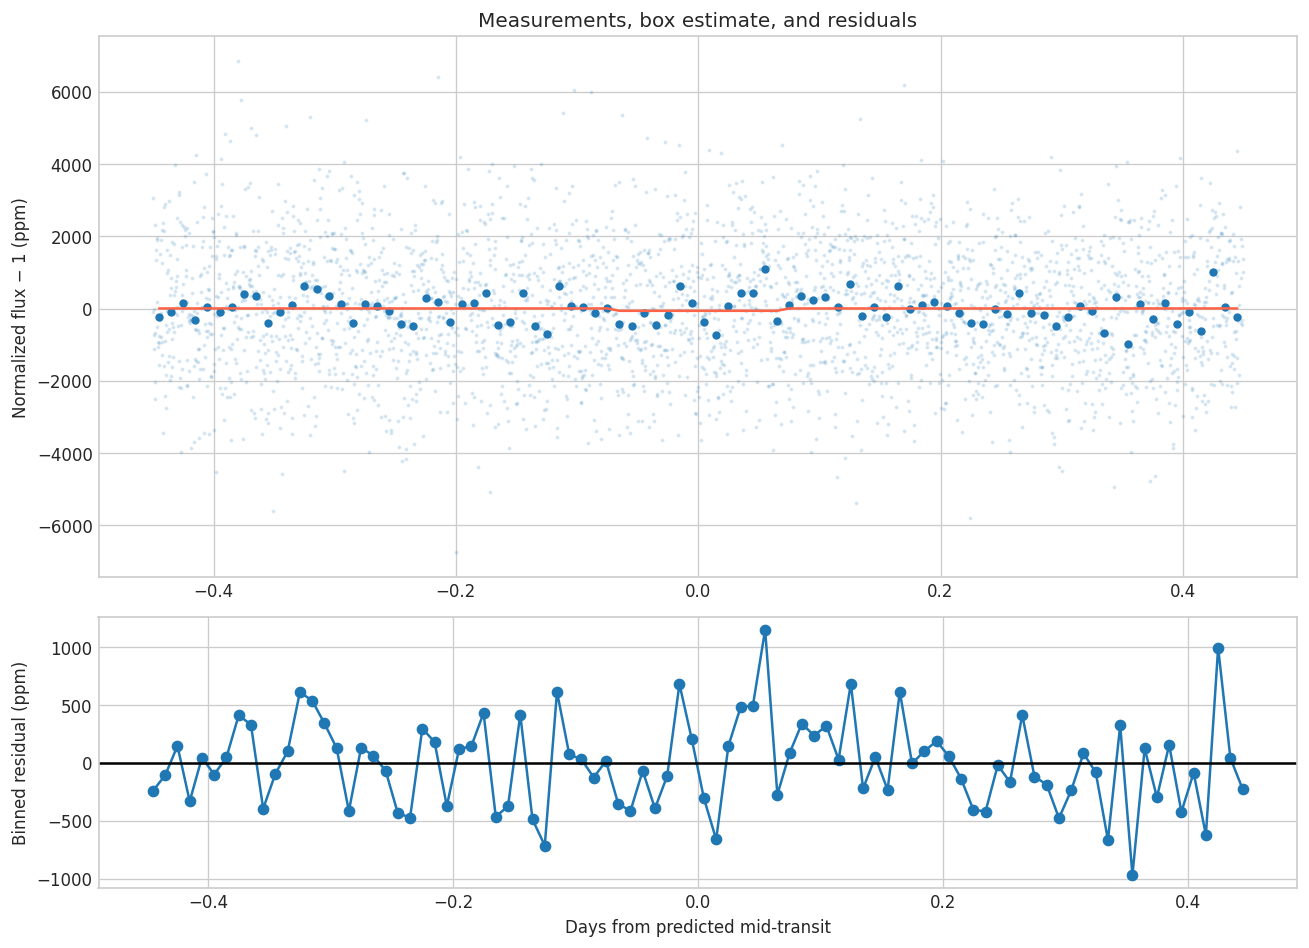

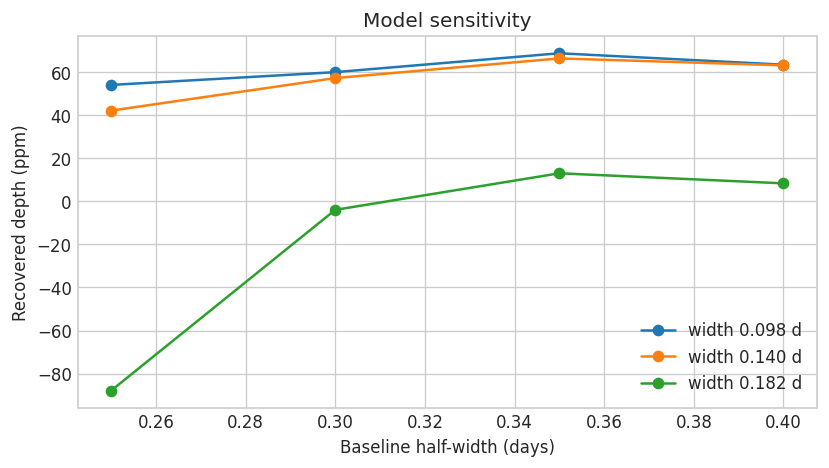

In [2]:
data=pd.read_csv('toi700_multisector_pdcsap.csv'); data=data[(data.quality==0)].dropna(); data['flux']=data.flux/data.flux.median() if 'tess'=='kepler' else data.flux; data['error']=data.error/data.error.median()*np.median(data['error']) if False else data.error; time=data.time.to_numpy(); flux=data.flux.to_numpy(); phase=((time-1937.6151+37.426/2)%37.426)-37.426/2
inside=np.abs(phase)<0.14/2; base=(np.abs(phase)>0.14)&(np.abs(phase)<.35); baseline=np.median(flux[base]); depth=baseline-np.median(flux[inside]); boot=[]
for _ in range(2000): boot.append(np.median(RNG.choice(flux[base],base.sum()))-np.median(RNG.choice(flux[inside],inside.sum())))
lo,hi=np.percentile(boot,[2.5,97.5]); scatter=np.std((flux[base]-baseline)*1e6); significant=bool(lo>0)
edges=np.linspace(-.45,.45,91); centres=(edges[:-1]+edges[1:])/2; idx=np.digitize(phase,edges); binned=np.array([np.median(flux[idx==i]) if (idx==i).any() else np.nan for i in range(1,len(edges))]); model=np.where(abs(centres)<0.14/2,baseline-depth,baseline)
fig,ax=plt.subplots(2,1,figsize=(11,8),gridspec_kw={'height_ratios':[2,1]}); use=abs(phase)<.45; ax[0].scatter(phase[use],(flux[use]-1)*1e6,s=2,alpha=.12); ax[0].plot(centres,(binned-1)*1e6,'o',ms=4); ax[0].plot(centres,(model-1)*1e6,color='tomato'); ax[0].set(ylabel='Normalized flux − 1 (ppm)',title='Measurements, box estimate, and residuals'); ax[1].plot(centres,(binned-model)*1e6,'o-'); ax[1].axhline(0,color='black'); ax[1].set(xlabel='Days from predicted mid-transit',ylabel='Binned residual (ppm)'); fig.tight_layout(); fig.savefig('toi700_transit_audit.png',dpi=180); plt.show()
tests=[]
for w in [0.098,0.14,0.18200000000000002]:
 for outer in [.25,.30,.35,.40]:
  ii=abs(phase)<w/2; oo=(abs(phase)>w)&(abs(phase)<outer); tests.append((w,outer,(np.median(flux[oo])-np.median(flux[ii]))*1e6))
stress=pd.DataFrame(tests,columns=['transit_width_days','baseline_half_width_days','depth_ppm']); stress.to_csv('toi700_model_sensitivity.csv',index=False); fig,ax=plt.subplots(figsize=(7,4));
for w,g in stress.groupby('transit_width_days'): ax.plot(g.baseline_half_width_days,g.depth_ppm,'o-',label=f'width {w:.3f} d')
ax.set(xlabel='Baseline half-width (days)',ylabel='Recovered depth (ppm)',title='Model sensitivity'); ax.legend(); fig.tight_layout(); fig.savefig('toi700_depth_sensitivity.png',dpi=180); plt.show()

In [3]:
summary=pd.DataFrame([{'period_days':37.426,'depth_ppm':depth*1e6,'ci_low_ppm':lo*1e6,'ci_high_ppm':hi*1e6,'baseline_scatter_ppm':scatter,'n_good':len(data)}]); summary.to_csv('toi700_fit_summary.csv',index=False)
signal=f'positive box-depth interval: {significant}' if significant else 'no significant transit recovered by this simple audit'; results=[signal,f'box depth {depth*1e6:.0f} ppm; 95% interval {lo*1e6:.0f}–{hi*1e6:.0f} ppm',f'baseline scatter {scatter:.0f} ppm']
result={'id':'2026-07-30-tess-lightcurve-toi700','title':'TOI-700 d: multi-sector transit coverage audit','archive':'MAST · TESS','date':'2026-07-30','question':'Does a simple multi-sector audit significantly recover the 37.426-day transit?','sample_size':int(len(data)),'results':results,'validation':'The depth is bootstrapped and repeated across twelve transit/baseline choices.','notebook':'mast/2026-07-30-tess-lightcurve-toi700/notebook.ipynb','hero':'mast/2026-07-30-tess-lightcurve-toi700/toi700_transit_audit.png','figures':['mast/2026-07-30-tess-lightcurve-toi700/toi700_transit_audit.png','mast/2026-07-30-tess-lightcurve-toi700/toi700_depth_sensitivity.png'],'research_level':'Exploration','claim_type':'Null / method-sensitive','provenance':['MAST product TESS SPOC sectors 27, 28, 30, 31, 33–36','quality flag = 0','PDCSAP flux'],'artifacts':['mast/2026-07-30-tess-lightcurve-toi700/toi700_multisector_pdcsap.csv','mast/2026-07-30-tess-lightcurve-toi700/toi700_fit_summary.csv','mast/2026-07-30-tess-lightcurve-toi700/toi700_model_sensitivity.csv'],'quality_checks':[{'name':'Archive product','status':'pass'},{'name':'Quality flags','status':'pass'},{'name':'Bootstrap interval','status':'pass'},{'name':'Model sensitivity','status':'caution'}],'limitations':['simple box model','correlated noise not fully modelled','published ephemeris assumed'],'tags':['transit','light curve','uncertainty']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')

no significant transit recovered by this simple audit
box depth 66 ppm; 95% interval -136–268 ppm
baseline scatter 1668 ppm


In [4]:
print(summary.to_string(index=False))

 period_days  depth_ppm  ci_low_ppm  ci_high_ppm  baseline_scatter_ppm  n_good
      37.426  66.360838 -136.089604   268.239581           1668.267753    7715


In [5]:
print(stress.to_string(index=False))

 transit_width_days  baseline_half_width_days  depth_ppm
              0.098                      0.25  54.041523
              0.098                      0.30  59.983174
              0.098                      0.35  68.746372
              0.098                      0.40  63.443822
              0.140                      0.25  42.127644
              0.140                      0.30  57.232325
              0.140                      0.35  66.360838
              0.140                      0.40  63.130832
              0.182                      0.25 -87.883105
              0.182                      0.30  -3.955379
              0.182                      0.35  13.026109
              0.182                      0.40   8.348626


In [6]:
assert lo<=depth<=hi

In [7]:
assert len(result['figures'])==2

## Interpretation and references

This is an archive remeasurement for learning, not independent planet
validation. A publication-grade analysis would jointly fit stellar variability,
dilution, limb darkening, cadence integration, correlated noise, and timing
uncertainty. An interval containing zero is retained as a null result.

- MAST archive: https://archive.stsci.edu/
- Kepler-10: https://doi.org/10.1088/0004-637X/729/1/27
- TOI-700 d: https://doi.org/10.3847/1538-3881/aba4b2